# Forecasting 
So we have an idea of how time series data looks and works, but now we wish to use it for something practical. In the case of the RNLI, it may well be you want to look at projected assists needed this summer, or what the tides will look like etc. We are going to go over some of the best ways of doing this, focusing on building up more and more complex models. <br>
This notebook will look at ARIMA, SARIMA and SARIMAX models, borrowing from: https://www.machinelearningplus.com/time-series/arima-model-time-series-forecasting-python/ (I recommend also reading this and other resources if there is anything here you are struggling to understand).

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
from dateutil.parser import parse

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_predict
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

import pmdarima as pm
from pmdarima.arima.utils import ndiffs


%matplotlib inline

## ARIMA
Autoregressive Integrated Moving Average or ARIMA models allow us to fit time series and so forecast new data. It is is an amalgamation of Autoregressive and Moving Average models with an integrated component that allows us to also figure out how many times we will need to apply differencing. <br>
ARIMA(p, d, q) has parameters: $p$ being the order of our AR process (number of time lags we need), $q$ being the order of our MA (how many terms needed to remove any autocorrelation), and a new parameter $d$. This represents the order of differencing ie the number of times we need to difference a series so it becomes stationary. <br>

### Order of Differencing 
As previously mentioned, we want to difference a series in order for us to be abe to get stationary from non-stationary time series. However, if we over-difference we may affect our other model parameters. Under-difference and we may not have a truly stationary dataset. The right order of $d$ is one wherein the ACF plot reaches 0 pretty quickly. A good rule of thumb is is the AC is positive for many number of lags (~10 or more), then we need a higher order. If lag 1 is too negative, we may have over-differenced. 

In [9]:
#Read in some dummy data based on internet usage
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/wwwusage.csv', names=['value'], header=0)
df

,value
0,88
1,84
2,85
3,85
4,84
...,...
95,222
96,228
97,226
98,222


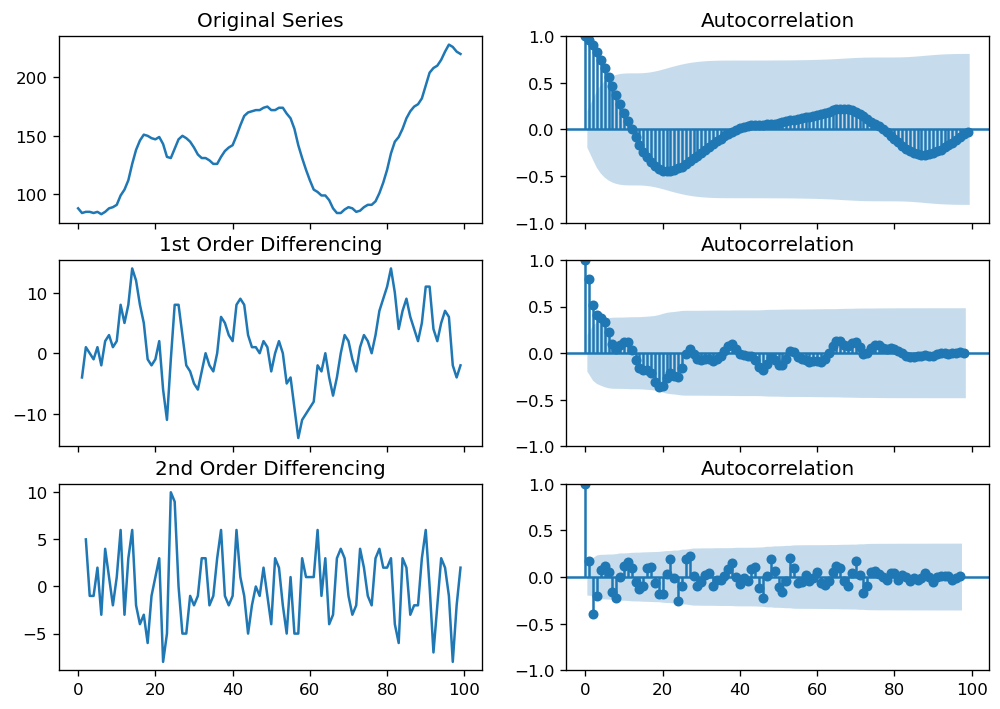

In [27]:
fig, axes = plt.subplots(3, 2, sharex=True) #make a set of subplots of dimenions 3x2 ie 3 rows and 2 columns

#Original
axes[0, 0].plot(df.value) 
axes[0, 0].set_title('Original Series') #plots the first figure in the top left with [0, 0] being the matrix element position
plot_acf(df.value, ax=axes[0, 1], lags = 99); #plots the acf on the next column along

#1st Order Differencing
axes[1, 0].plot(df.value.diff())
axes[1, 0].set_title('1st Order Differencing')
plot_acf(df.value.diff().dropna(), ax=axes[1, 1], lags = 98); #differencing drops number of lags by 1

# 2nd Order Differencing
axes[2, 0].plot(df.value.diff().diff())
axes[2, 0].set_title('2nd Order Differencing')
plot_acf(df.value.diff().diff().dropna(), ax=axes[2, 1], lags = 97);

plt.show()

We can see that stationarity is reached within two orders of differencing, but the ACF plot shows that we have a high negative value at very early lags, so this could be over-differencing. We set the differencing order to be 1, even though the first order is only weakly staionary, as a first step. <br>
We can do a double check on the order of differencing by employing ndiffs(), a function from pmdarima.

In [29]:
ndiffs(df.value, test = 'adf') #ADF used here, but we can use other statistical test similar 

2

We can see that this agrees with the differencing we have just done ie 2. However, we are still going to go with our judgement as statisticians for now!

### Order of MA(q)
We can find the order of $q$ by answering the question: in the ACF plot, how many lags is it before we reach one that fits in our confidence band (shaded area)? Remember that the first point on the ACF plot is at 0 so we ignore this (0 lags would mean we don't take any steps at all). From the order-1 differencing, we can see that there are 2 lags well above the significance, but this lowered considerably when it gets to lag 3. Therefore, we (tentatively) fix $q$ as 2.

### Order of AR(p)
To find the order of $p$ we inspect the PACF plot and look to see which lag the PACF is significant.

C:\Users\Joe_Davies\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


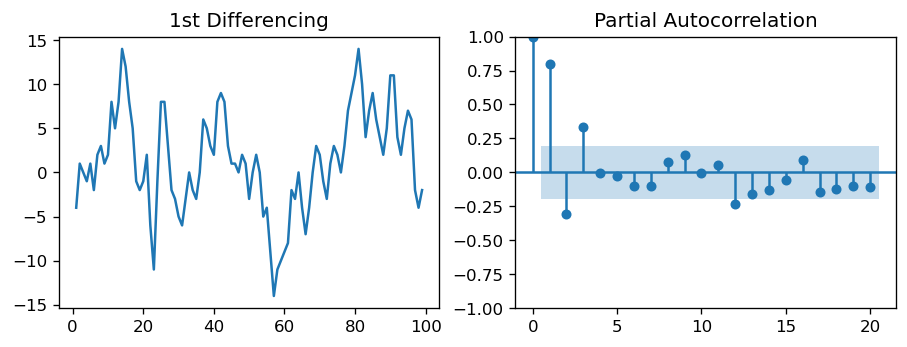

In [37]:
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})
fig, axes = plt.subplots(1, 2, sharex=False)
axes[0].plot(df.value.diff()) 
axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0,5))
plot_pacf(df.value.diff().dropna(), ax=axes[1]);
plt.show()

We can see that lag 1 is significant, but the second is not nearly as so. We set $p$ to be 1.

If your time series is a little over-differenced, it's best to add another MA term (increase $q$ by 1). <br>
If your time series is a little under-differenced, it's best to add another AR term (increase $p$ by 1).

## Building ARIMA
We now have a tentative first look at what the model parameters should be ie ARIMA(p=1, d=1, q=2). Let's build that model!

In [48]:
model = ARIMA(df.value, order = (1, 1, 2)) #set our model to be ARIMA and set the orders
model_fit = model.fit() #fit the model ie run the data we have through our model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -254.126
Date:                Mon, 01 Aug 2022   AIC                            516.253
Time:                        16:18:27   BIC                            526.633
Sample:                             0   HQIC                           520.453
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6976      0.130      5.365      0.000       0.443       0.952
ma.L1          0.4551      0.169      2.699      0.007       0.125       0.786
ma.L2         -0.0664      0.157     -0.424      0.6

There is a lot to be learned here and a lot of it is a little out of scope of this notebook. For our purposes, we want to focus on the middle row. <br>
The coef (coefficient) column are the weight terms we have seen in the previous notebook. The coefficient of the 2nd term in MA (ma.L2) is very close to 0 and the p-value (P>|z| column) is much higher than 0.05. As a result, it would show that this is highly insignificant, so we should actually drop the $q$ term to 1. Let's remake the model with that in mind.

In [49]:
model = ARIMA(df.value, order = (1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -254.150
Date:                Mon, 01 Aug 2022   AIC                            514.300
Time:                        16:18:32   BIC                            522.086
Sample:                             0   HQIC                           517.450
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6504      0.090      7.258      0.000       0.475       0.826
ma.L1          0.5256      0.088      5.994      0.000       0.354       0.697
sigma2         9.7934      1.405      6.970      0.0

We can see that the p-value and coefficient are now within reasonable values. To make sure, we can plot the residuals to see if there are truly no patterns.

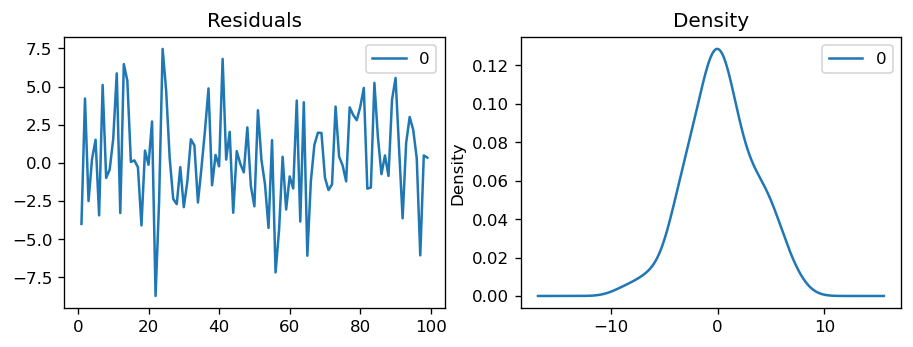

In [67]:
plt.rcParams.update({'figure.figsize':(9, 3), 'figure.dpi':120})
residuals = pd.DataFrame(model_fit.resid[1:]) #make a dataframe from the residuals, accessed by model_fit.resid
#In the above, I do not include the first point, as this give a spike at 0, which we can get rid of
fig, ax = plt.subplots(1, 2)
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

There is a lack of any patterns here and the density is centered around 0 (ie there is a mean of 0). <br>
The density is calculated using Kernel Density Estimation (KDE) which is something commonly used in statistics for probability density estimation. It applies something known as kernel smoothing, which is the process of estimating a function as a weighted average of neighbouring data with closer points given higher weights. <br>
We can now see how well our forecast fits the original data.

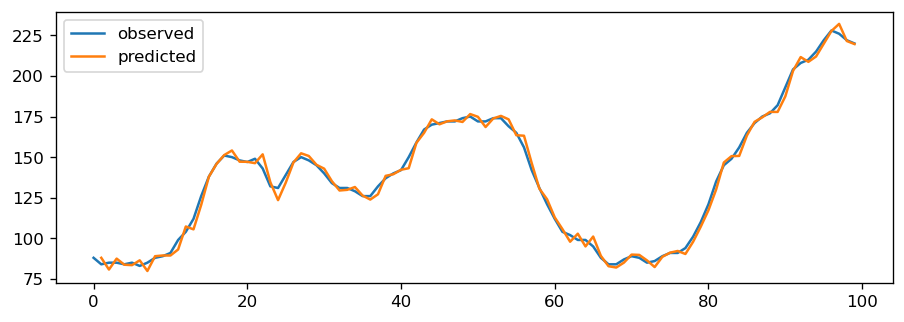

In [71]:
res = model_fit.predict()[1:] #we predict using our fitted model (note that I again don't include the first element at 0)
plt.plot(df.value, label = 'observed') #I give labels to the different plotted data terms so that we can make a legend easily
plt.plot(res, label = 'predicted')
plt.legend()
plt.show()

Great! Our model fits the data well! Or, at least it fits the current data. Without forecasting into the future, it will be difficult to understand how well the data is actually doing. In order to find the optimal ARIMA model (manually) we use Out-of-Time Cross Validation.

## Out-of-Time Cross Validation
This is a method of testing which model works best. It works by taking some steps back in the data (lags) and then forecasting as many steps forward as we took. We compare this to actual data and see how it looks. In order to to this we need to make a reasonable test/train split choice for our data. Usually when picking test/train in machine learning we have the ability to make some arbitrary choice of data. In time series, points must retain their sequence. For this reason, it is best to take the last few lags of data. For instance, if we have 5 years of data, take the last year of data to be the test with the rest being train. IT IS VERY IMPORTANT YOU HAVE MORE TRAINING DATA THAN TESTING! <br>
After this is done, we can adjust $p$, $d$, and $q$ accordingly. We are looking for the model that gives the lowest Akaike Information Criterion (AIC). This measures how well a model fits data in forecasting, according to: $AIC = 2k-2ln(L)$ where: $k$ is number of independent variables, $ln()$ is the natural logarithm (logarithm to the base $e \simeq 2.72$, and $L$ is the likelihood that the model produces the observed output values. AIC and log likelihood are both found in the summary of the model (first section).

In [72]:
train = df.value[:85]
test = df.value[85:]

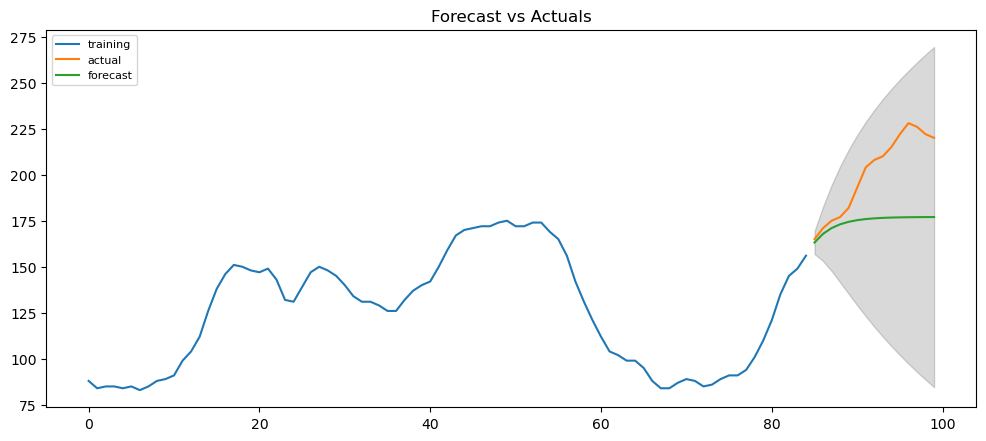

In [124]:
model = ARIMA(train, order=(1, 1, 1))  
fitted = model.fit()  

# Forecast
fc = fitted.get_forecast(15) #15 forecast lags past training
conf = fc.conf_int(alpha = 0.05)

# Make as pandas series which is how column data is actually stored
fc_series = fc.predicted_mean
lower_series = conf['lower value']
upper_series = conf['upper value']

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.15) #fills the space between our two confidence bands with some colour
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

Clearly we have a different forecast to the actual, meaning our model here isn't so good. Each of the predicted forecasts are below the actual values. We can see how well we are performing using one of the performance metrics for time series. There are many to choose from, but one of the more common and easy to understand is Mean Absolute Percentage Error (MAPE) which is: $MAPE = mean(|forecasted - actual|/|actual|)$. The lower the percentage, the better. A value of 0.032 means an accuracy of 96.8%. 

In [130]:
mape = np.mean(np.abs(fc_series - test.values)/np.abs(test.values))
print('MAPE Value: {}\nModel Accuracy: {}%'.format(round(mape, 4), round(100-(mape*100), 2)))

MAPE Value: 0.1252
Model Accuracy: 87.48%


If we want to improve our model, we could spend time going through each iteration of values and seeing which gives the lowest AIC. Alternatively, we can use the automatic function to handle this for us!

In [135]:
model = pm.auto_arima(train, #data to train on
                      start_p = 1, #starting p 
                      start_q = 1, #starting q
                      test = 'adf', #test used
                      max_p = 3, #max value for p
                      max_q = 3, #max value for q
                      d = None, #allow the model to figure out d
                      seasonal = False, #no seasonality in the model
                      trace = True #print status on the fits
                     )
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=447.705, Time=0.09 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=451.549, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=451.463, Time=0.02 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=447.707, Time=0.03 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=449.662, Time=0.01 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=441.862, Time=0.09 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=439.922, Time=0.05 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=441.881, Time=0.07 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=438.156, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=449.569, Time=0.01 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=440.125, Time=0.03 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=440.111, Time=0.04 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=445.820, Time=0.03 sec
 ARIMA(3,2,1)(0,0,0)[0]             : AIC=inf, Time

So our best model is (2, 2, 0) with the p-values and AIC looking good. Let's plot!

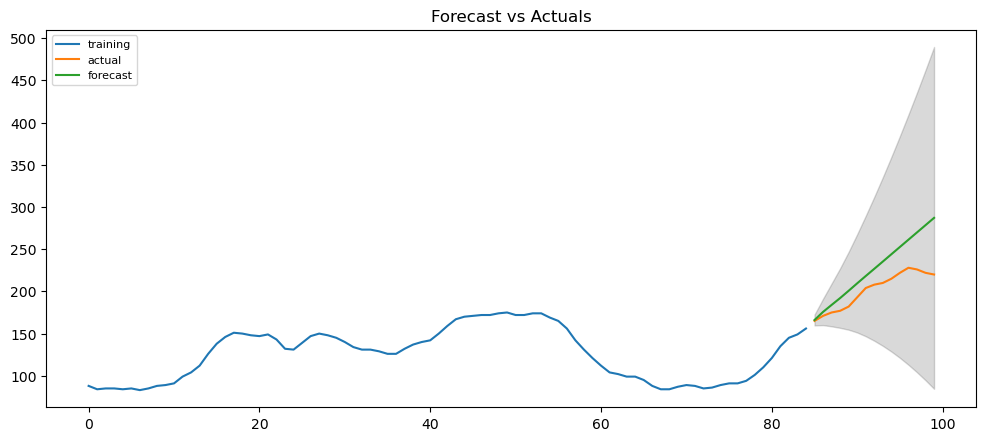

In [136]:
model = ARIMA(train, order=(2, 2, 0))  
fitted = model.fit()  

# Forecast
fc = fitted.get_forecast(15) #15 forecast lags past training
conf = fc.conf_int(alpha = 0.05)

# Make as pandas series which is how column data is actually stored
fc_series = fc.predicted_mean
lower_series = conf['lower value']
upper_series = conf['upper value']

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.15) #fills the space between our two confidence bands with some colour
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [137]:
mape = np.mean(np.abs(fc_series - test.values)/np.abs(test.values))
print('MAPE Value: {}\nModel Accuracy: {}%'.format(round(mape, 4), round(100-(mape*100), 2)))

MAPE Value: 0.1209
Model Accuracy: 87.91%


The accuracy seems to be fine but the forecast isn't perfect still. It may well be that our assumption of the original dataset having no seasonality was incorrect, and a slightly more complex model is needed.

## Seasonal ARIMA (SARIMA(p, d, q)x(P, D, Q)
ARIMA does not support seasonality and so SARIMA uses seasonal differencing to get around this. Instead of subtracting consecutive terms, it subtracts some value from the previous season. This is represented by the x(P, D, Q) term where we have: SAR(P), SMA(Q) and SD(D) being the seasonal versions of p, q, and d.<br>
Generally, if a series has well defined seasonal patterns, we should set D=1 (or 0). the total differencing d+D shouldn't really exceed 2, D not exceeding 1. Try to keep only either SAR or SMA terms if there is seasonality. 

In [146]:
smodel = pm.auto_arima(train, 
                      start_p = 1, 
                      start_q = 1, 
                      max_p = 3, 
                      max_q = 3, 
                      m = 4, #set the number of intervals we have. I am asssuming 4 based on the training plot
                      seasonal = True, 
                      start_P = 0, 
                      d = None, 
                      D = 1, 
                      trace = True)
smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[4] intercept   : AIC=467.287, Time=0.15 sec
 ARIMA(0,0,0)(0,1,0)[4] intercept   : AIC=716.275, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[4] intercept   : AIC=537.751, Time=0.10 sec
 ARIMA(0,0,1)(0,1,1)[4] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(0,0,0)(0,1,0)[4]             : AIC=716.143, Time=0.02 sec
 ARIMA(1,0,1)(0,1,0)[4] intercept   : AIC=468.899, Time=0.08 sec
 ARIMA(1,0,1)(1,1,1)[4] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(1,0,1)(0,1,2)[4] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(1,0,1)(1,1,0)[4] intercept   : AIC=469.256, Time=0.12 sec
 ARIMA(1,0,1)(1,1,2)[4] intercept   : AIC=inf, Time=0.54 sec
 ARIMA(1,0,0)(0,1,1)[4] intercept   : AIC=533.971, Time=0.10 sec
 ARIMA(2,0,1)(0,1,1)[4] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(1,0,2)(0,1,1)[4] intercept   : AIC=inf, Time=0.42 sec
 ARIMA(0,0,0)(0,1,1)[4] intercept   : AIC=696.705, Time=0.05 sec
 ARIMA(0,0,2)(0,1,1)[4] intercept   : AIC=527.858, Time=0.22 sec
 ARIMA

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                   85
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 4)   Log Likelihood                -228.842
Date:                           Mon, 01 Aug 2022   AIC                            465.684
Time:                                   18:48:52   BIC                            475.262
Sample:                                        0   HQIC                           469.527
                                            - 85                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9580      0.043     22.361      0.000       0.874       1.042
ma.L1          0.9418      0.056     16.825      0.000       0.832       1.052
ma.S.L4       -0.3359      0.147     -2.293      0.022      -0.623      -0.049
sigma2        15.3885      2.766      5.564      0.000       9.967      20.810
===================================================================================
Ljung-Box (L1) (Q):                   8.03   Jarque-Bera (JB):                 0.44
Prob(Q):                              0.00   Prob(JB):                         0.80
Heteroskedasticity (H):               0.84   Skew:                            -0.05
Prob(H) (two-sided):                  0.65   Kurtosis:                         2.65
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

AIC is lower and the p-values look great! We can plot the winning model SARIMA(1, 0, 1)x(0, 1, 1).

C:\Users\Joe_Davies\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Joe_Davies\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


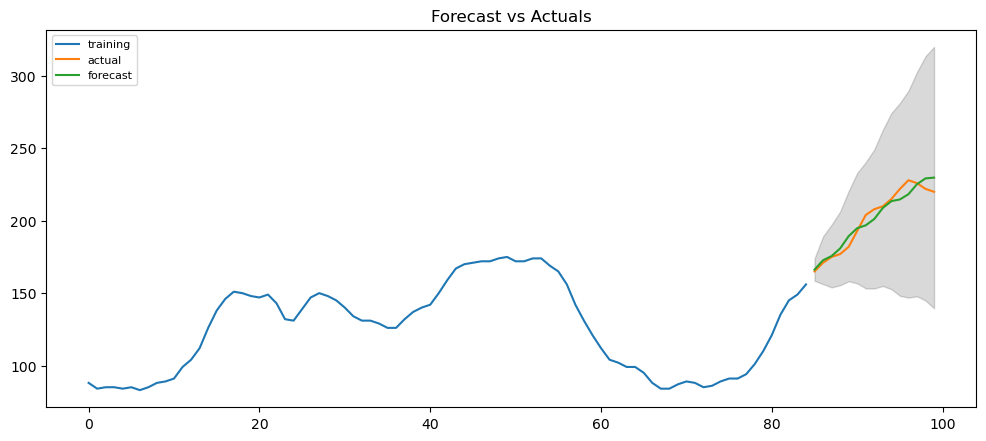

In [147]:
smodel = SARIMAX(train, order=(1, 0, 1), seasonal_order = (0, 1, 1, 4)) #this 4 on the end represents how many steps we have 
fitted = smodel.fit()  

# Forecast
fc = fitted.get_forecast(15) #15 forecast lags past training
conf = fc.conf_int(alpha = 0.05)

# Make as pandas series which is how column data is actually stored
fc_series = fc.predicted_mean
lower_series = conf['lower value']
upper_series = conf['upper value']

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.15) #fills the space between our two confidence bands with some colour
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

We now have a much better agreement!

## SARIMAX
This is SARIMA but with an exogenous variable. An exogenous variable is synonymous with an independent variable. An example would be if we had a farmer trying to get a bigger crop yield. The endogenous (dependent) variables would be things like fertilizer amount, type of soil etc and exogenous could be rainfall, sunlight, temperature etc. <br>
To be clear, this is not something that you will likely need to continue with. We can tweak the above by seeing if m=4 was really the best value, but usually we will have a very well defined seasonal element that is easy to see. Setting m in auto arima is something that is discussed in the documentation, but m=12 would give us monthly, for example. 7 is daily, 52 weekly etc. More information can be found here: https://alkaline-ml.com/pmdarima/tips_and_tricks.html#period. <br>
The data we have doesn't particulary support this as we don't actually have dates (the seasonality was imposed by me by looking at the graph) so we will switch  data to one that actually has dates! We will be setting the exogenous variable to the seasonal index, something that comes from decomposition of time series into trend, season and residual. 

In [151]:
data = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'], index_col='date')

In [152]:
# multiplicative seasonal component
result_mul = seasonal_decompose(data['value'][-36:],   # 3 years of data
                                model='multiplicative', 
                                extrapolate_trend='freq')

seasonal_index = result_mul.seasonal[-12:].to_frame() #monthly
seasonal_index['month'] = pd.to_datetime(seasonal_index.index).month

# merge with the base data
data['month'] = data.index.month
df = pd.merge(data, seasonal_index, how='left', on='month')
df.columns = ['value', 'month', 'seasonal_index']
df.index = data.index  # reassign the index.

In [154]:
sxmodel = pm.auto_arima(df[['value']], exogenous=df[['seasonal_index']], #exogenous variable set to the seasonal index
                           start_p=1, start_q=1,
                           test='adf',
                           max_p=3, max_q=3, m=12,
                           start_P=0, seasonal=True,
                           d=None, D=1, trace=True)

sxmodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=536.818, Time=0.88 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=626.061, Time=0.07 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=598.068, Time=0.51 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=613.475, Time=0.27 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=759.274, Time=0.12 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=561.407, Time=0.31 sec
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=inf, Time=1.55 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=538.817, Time=2.45 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=545.106, Time=0.95 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=539.510, Time=4.47 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=596.467, Time=0.32 sec
 ARIMA(2,0,1)(0,1,1)[12] intercept   : AIC=531.829, Time=0.92 sec
 ARIMA(2,0,1)(0,1,0)[12] intercept   : AIC=557.198, Time=0.34 sec
 ARIMA(2,0,1)(1,1,1)[12] intercept   : AIC=inf, Time=1.89 sec
 ARIMA(2,0,1)(0,1,2)[12] intercept   : AI

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  204
Model:             SARIMAX(1, 0, 2)x(1, 1, 2, 12)   Log Likelihood                -254.029
Date:                            Mon, 01 Aug 2022   AIC                            526.059
Time:                                    19:18:02   BIC                            555.376
Sample:                                07-01-1991   HQIC                           537.932
                                     - 06-01-2008                                         
Covariance Type:                              opg                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          0.0046      0.008      0.539      0.590      -0.012       0.021
seasonal_index  7.718e-07   9759.222   7.91e-11      1.000   -1.91e+04    1.91e+04
ar.L1              0.9774      0.018     55.300      0.000       0.943       1.012
ma.L1             -0.9159      0.055    -16.505      0.000      -1.025      -0.807
ma.L2              0.2161      0.058      3.738      0.000       0.103       0.329
ar.S.L12           0.8526      0.172      4.951      0.000       0.515       1.190
ma.S.L12          -1.5710      0.193     -8.119      0.000      -1.950      -1.192
ma.S.L24           0.7388      0.116      6.388      0.000       0.512       0.965
sigma2             0.7475      0.062     12.012      0.000       0.626       0.869
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):               144.42
Prob(Q):                              0.70   Prob(JB):                         0.00
Heteroskedasticity (H):              14.62   Skew:                             0.30
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

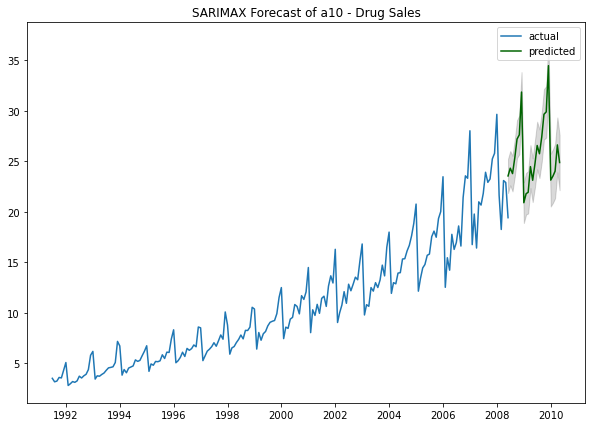

In [167]:
# Forecast

n_periods = 24
fitted, confint = sxmodel.predict(n_periods=n_periods, 
                                  #below we repeat the seasonal index for our 24 periods (2 years) using np.tile
                                  exogenous=np.tile(seasonal_index.seasonal, 2).reshape(-1, 1), #reshape to a 2-D array
                                  return_conf_int=True) #return the confidence interval

index_of_fc = pd.date_range(data.index[-1], periods = n_periods, freq='MS') #'MS' being months

# make series for plotting purpose
fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

# Plot
plt.figure(figsize=(10, 7))
plt.plot(data['value'], label = 'actual')
plt.plot(fitted_series, color='darkgreen', label = 'predicted')
plt.fill_between(lower_series.index, 
                 lower_series, 
                 upper_series, 
                 color='k', alpha=.15)
plt.legend()
plt.title("SARIMAX Forecast of a10 - Drug Sales")
plt.show()

# Conclusions
We now have all the tools we need to do time series analysis and forecasting! 